In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
S0 = 100        # Starting stock price in dollars
mu = 0.10       # Expected annual return (10%)
sigma = 0.20    # Annual volatility (20%)
T = 1           # Time horizon in years (1 year)
dt = 1/252      # One trading day as a fraction of a year
N = int(T / dt) # Total number of time steps (252 days)

print(f"Simulating {N} trading days")
print(f"Starting price: ${S0}")
print(f"Annual drift: {mu*100}%")
print(f"Annual volatility: {sigma*100}%")

Simulating 252 trading days
Starting price: $100
Annual drift: 10.0%
Annual volatility: 20.0%


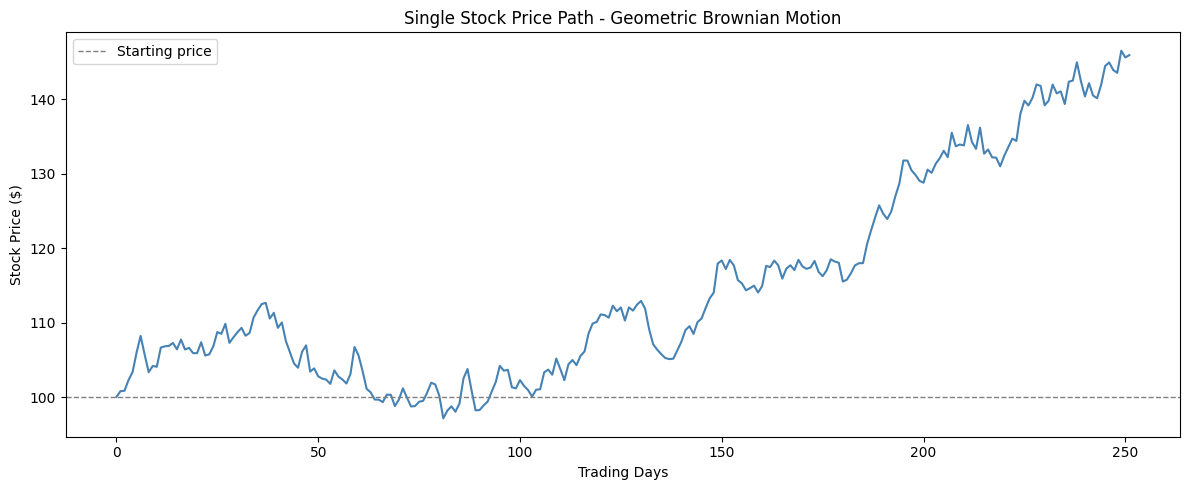

Starting price: $100.00
Ending price:   $145.96
Total return:   45.96%


In [6]:
# Create an array to store prices, day 0 starts at S0
prices = np.zeros(N)
prices[0] = S0

# Simulate one price path day by day
for t in range(1, N):
    random_shock = np.random.normal(0, 1)
    prices[t] = prices[t-1] * np.exp(
        (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * random_shock
    )

# Plot the single path
plt.figure(figsize=(12, 5))
plt.plot(prices, color='steelblue', linewidth=1.5)
plt.title('Single Stock Price Path - Geometric Brownian Motion')
plt.xlabel('Trading Days')
plt.ylabel('Stock Price ($)')
plt.axhline(y=S0, color='gray', linestyle='--', linewidth=1, label='Starting price')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Starting price: ${prices[0]:.2f}")
print(f"Ending price:   ${prices[-1]:.2f}")
print(f"Total return:   {((prices[-1]/prices[0]) - 1)*100:.2f}%")

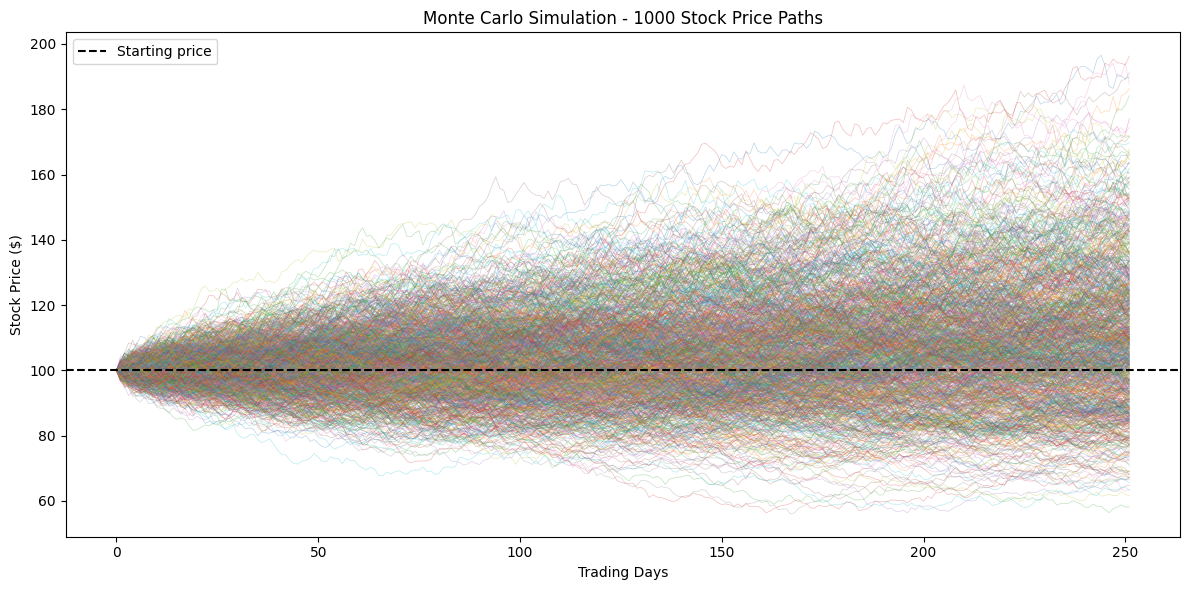

Simulations run: 1000
Final price - Minimum:  $58.15
Final price - Maximum:  $196.32
Final price - Average:  $110.34


In [5]:
# Number of simulations
num_simulations = 1000

# Generate all random shocks at once
# Shape is (N-1, num_simulations): 251 days, 1000 simulations
random_shocks = np.random.normal(0, 1, (N-1, num_simulations))

# Calculate daily returns using GBM formula
daily_returns = np.exp(
    (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * random_shocks
)

# Build price paths
# Start with a row of S0, then multiply cumulatively day by day
price_paths = np.zeros((N, num_simulations))
price_paths[0] = S0
price_paths[1:] = S0 * np.cumprod(daily_returns, axis=0)

# Plot all paths
plt.figure(figsize=(12, 6))
plt.plot(price_paths, linewidth=0.5, alpha=0.3)
plt.title('Monte Carlo Simulation - 1000 Stock Price Paths')
plt.xlabel('Trading Days')
plt.ylabel('Stock Price ($)')
plt.axhline(y=S0, color='black', linestyle='--', linewidth=1.5, label='Starting price')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Simulations run: {num_simulations}")
print(f"Final price - Minimum:  ${price_paths[-1].min():.2f}")
print(f"Final price - Maximum:  ${price_paths[-1].max():.2f}")
print(f"Final price - Average:  ${price_paths[-1].mean():.2f}")

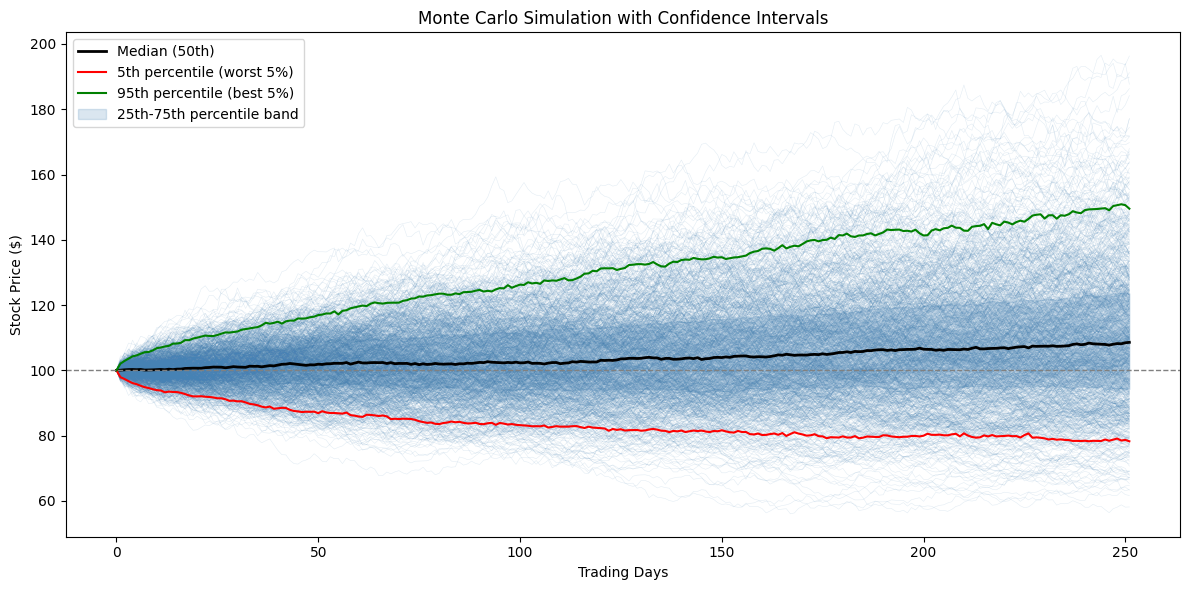

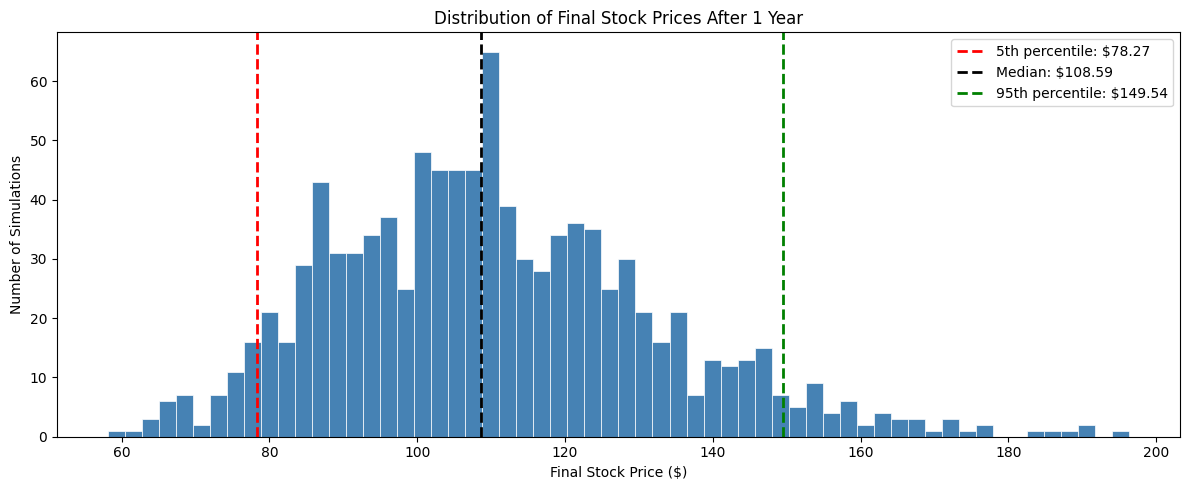

---- Risk Summary ----
Starting price:        $100.00
Median final price:    $108.59
5th percentile price:  $78.27
95th percentile price: $149.54
Value at Risk (95%):   $21.73
Meaning: In the worst 5% of outcomes, you lose at least $21.73 per $100 invested


In [7]:
# Calculate confidence interval percentiles across all days
percentile_5  = np.percentile(price_paths, 5,  axis=1)
percentile_25 = np.percentile(price_paths, 25, axis=1)
percentile_50 = np.percentile(price_paths, 50, axis=1)
percentile_75 = np.percentile(price_paths, 75, axis=1)
percentile_95 = np.percentile(price_paths, 95, axis=1)

days = np.arange(N)

# Plot 1: Price paths with confidence bands
plt.figure(figsize=(12, 6))
plt.plot(price_paths, linewidth=0.4, alpha=0.15, color='steelblue')
plt.plot(days, percentile_50, color='black',  linewidth=2,   label='Median (50th)')
plt.plot(days, percentile_5,  color='red',    linewidth=1.5, label='5th percentile (worst 5%)')
plt.plot(days, percentile_95, color='green',  linewidth=1.5, label='95th percentile (best 5%)')
plt.fill_between(days, percentile_25, percentile_75, alpha=0.2, color='steelblue', label='25th-75th percentile band')
plt.axhline(y=S0, color='gray', linestyle='--', linewidth=1)
plt.title('Monte Carlo Simulation with Confidence Intervals')
plt.xlabel('Trading Days')
plt.ylabel('Stock Price ($)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Plot 2: Distribution of final prices
final_prices = price_paths[-1]

plt.figure(figsize=(12, 5))
plt.hist(final_prices, bins=60, color='steelblue', edgecolor='white', linewidth=0.5)
plt.axvline(x=np.percentile(final_prices, 5),  color='red',   linewidth=2, linestyle='--', label=f'5th percentile: ${np.percentile(final_prices, 5):.2f}')
plt.axvline(x=np.percentile(final_prices, 50), color='black', linewidth=2, linestyle='--', label=f'Median: ${np.percentile(final_prices, 50):.2f}')
plt.axvline(x=np.percentile(final_prices, 95), color='green', linewidth=2, linestyle='--', label=f'95th percentile: ${np.percentile(final_prices, 95):.2f}')
plt.title('Distribution of Final Stock Prices After 1 Year')
plt.xlabel('Final Stock Price ($)')
plt.ylabel('Number of Simulations')
plt.legend()
plt.tight_layout()
plt.show()

# Print the risk summary
var_95 = S0 - np.percentile(final_prices, 5)
print("---- Risk Summary ----")
print(f"Starting price:        ${S0:.2f}")
print(f"Median final price:    ${np.percentile(final_prices, 50):.2f}")
print(f"5th percentile price:  ${np.percentile(final_prices, 5):.2f}")
print(f"95th percentile price: ${np.percentile(final_prices, 95):.2f}")
print(f"Value at Risk (95%):   ${var_95:.2f}")
print(f"Meaning: In the worst 5% of outcomes, you lose at least ${var_95:.2f} per $100 invested")

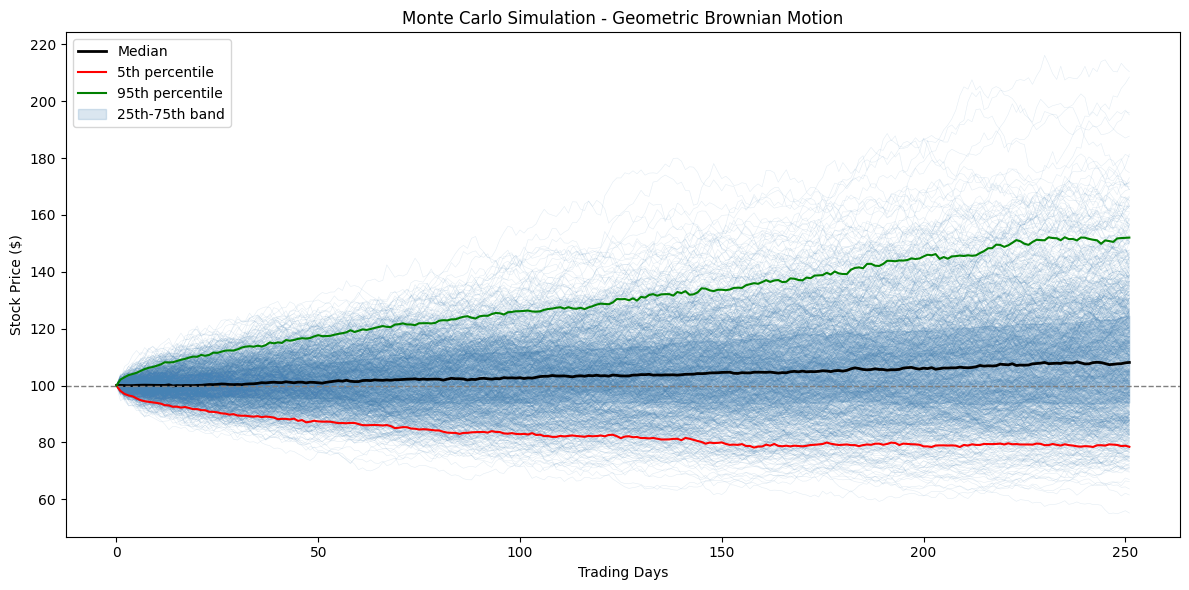

---- Risk Summary ----
Starting price:        $100.00
Median final price:    $108.14
5th percentile price:  $78.47
95th percentile price: $152.03
Value at Risk (95%):   $21.53
Meaning: In the worst 5% of outcomes, you lose at least $21.53 per $100 invested


In [8]:
def run_monte_carlo(S0, mu, sigma, T, num_simulations):
    """
    Simulate stock price paths using Geometric Brownian Motion.

    Parameters:
        S0              : float - Starting stock price
        mu              : float - Expected annual return (e.g. 0.10 for 10%)
        sigma           : float - Annual volatility (e.g. 0.20 for 20%)
        T               : float - Time horizon in years
        num_simulations : int   - Number of simulation paths

    Returns:
        price_paths : numpy array of shape (N, num_simulations)
    """
    dt = 1 / 252
    N  = int(T / dt)

    random_shocks = np.random.normal(0, 1, (N - 1, num_simulations))
    daily_returns = np.exp(
        (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * random_shocks
    )

    price_paths    = np.zeros((N, num_simulations))
    price_paths[0] = S0
    price_paths[1:] = S0 * np.cumprod(daily_returns, axis=0)

    return price_paths


def summarise_simulation(price_paths, S0):
    """
    Print a risk summary and plot results for a completed simulation.
    """
    final_prices = price_paths[-1]
    days         = np.arange(len(price_paths))

    p5  = np.percentile(final_prices, 5)
    p25 = np.percentile(final_prices, 25)
    p50 = np.percentile(final_prices, 50)
    p75 = np.percentile(final_prices, 75)
    p95 = np.percentile(final_prices, 95)

    # Chart
    plt.figure(figsize=(12, 6))
    plt.plot(price_paths, linewidth=0.4, alpha=0.15, color='steelblue')
    plt.plot(days, np.percentile(price_paths, 50, axis=1), color='black',  linewidth=2,   label='Median')
    plt.plot(days, np.percentile(price_paths, 5,  axis=1), color='red',    linewidth=1.5, label='5th percentile')
    plt.plot(days, np.percentile(price_paths, 95, axis=1), color='green',  linewidth=1.5, label='95th percentile')
    plt.fill_between(days,
                     np.percentile(price_paths, 25, axis=1),
                     np.percentile(price_paths, 75, axis=1),
                     alpha=0.2, color='steelblue', label='25th-75th band')
    plt.axhline(y=S0, color='gray', linestyle='--', linewidth=1)
    plt.title('Monte Carlo Simulation - Geometric Brownian Motion')
    plt.xlabel('Trading Days')
    plt.ylabel('Stock Price ($)')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

    # Risk summary
    print("---- Risk Summary ----")
    print(f"Starting price:        ${S0:.2f}")
    print(f"Median final price:    ${p50:.2f}")
    print(f"5th percentile price:  ${p5:.2f}")
    print(f"95th percentile price: ${p95:.2f}")
    print(f"Value at Risk (95%):   ${S0 - p5:.2f}")
    print(f"Meaning: In the worst 5% of outcomes, you lose at least ${S0 - p5:.2f} per ${S0:.0f} invested")


# Run with our original parameters
paths = run_monte_carlo(S0=100, mu=0.10, sigma=0.20, T=1, num_simulations=1000)
summarise_simulation(paths, S0=100)